In [1]:
#libraries in medical imaging
!pip install pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 26.5 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Summary of the dataset

In [49]:
import os
import plistlib
import pandas as pd
import pydicom

patient_root = "/content/drive/MyDrive/AI_Medical/COCA/raw_data/gated_files/patient"
xml_root = "/content/drive/MyDrive/AI_Medical/COCA/raw_data/gated_files/calcium_xml"

summary = []

patients = sorted(
    patient
    for patient in os.listdir(patient_root)
    if not patient.startswith(".")
    and os.path.isdir(os.path.join(patient_root, patient))
)

for patient in patients:

    patient_folder = os.path.join(patient_root, patient)

    # Count DICOM files recursively
    dicom_files = []

    for current_folder, subfolders, filenames in os.walk(patient_folder):
        for filename in filenames:
            if (
                filename.lower().endswith(".dcm")
                and not filename.startswith(".")
            ):
                dicom_files.append(
                    os.path.join(current_folder, filename)
                )

    xml_file = os.path.join(xml_root, f"{patient}.xml")

    total_rois = 0
    polygon_rois = 0

    # Read the Apple plist XML
    if os.path.exists(xml_file):

        with open(xml_file, "rb") as f:
            annotation = plistlib.load(f)

        images_info = annotation.get("Images", [])

        for image_entry in images_info:

            rois = image_entry.get("ROIs", [])

            total_rois += len(rois)

            for roi in rois:

                number_of_points = roi.get(
                    "NumberOfPoints",
                    0
                )

                if number_of_points > 0:
                    polygon_rois += 1

    summary.append({
        "Patient": patient,
        "DICOM slices": len(dicom_files),
        "Total ROIs": total_rois,
        "Polygon ROIs": polygon_rois
    })

summary_df = pd.DataFrame(summary)

print("Total patients:", len(summary_df))

summary_df.head()

Total patients: 787


,Patient,DICOM slices,Total ROIs,Polygon ROIs
0,0,57,2,1
1,1,57,20,16
2,10,46,19,18
3,100,46,29,28
4,101,49,7,1


In [50]:
# Check patient 135
summary_df[
    summary_df["Patient"].astype(str) == "135"
]

,Patient,DICOM slices,Total ROIs,Polygon ROIs
40,135,46,19,3


## Table containing every calcium lesion

In [51]:
import os
import plistlib
import pandas as pd

records = []

for patient in patients:

    xml_file = os.path.join(xml_root, f"{patient}.xml")

    if not os.path.exists(xml_file):
        continue

    with open(xml_file, "rb") as f:
        annotation = plistlib.load(f)

    images = annotation.get("Images", [])

    for image in images:

        image_index = image.get("ImageIndex")

        for roi in image.get("ROIs", []):

            records.append({

                "Patient": patient,

                "ImageIndex": image_index,

                "Artery": roi.get("Name"),

                "NumberOfPoints": roi.get("NumberOfPoints", 0),

                "Area": roi.get("Area")

            })

roi_df = pd.DataFrame(records)

print("Total ROIs:", len(roi_df))

roi_df.head()

Total ROIs: 9146


,Patient,ImageIndex,Artery,NumberOfPoints,Area
0,0,34,Right Coronary Artery,20,0.029283
1,0,35,Right Coronary Artery,0,0.000000
2,1,12,Right Coronary Artery,20,0.026378
3,1,19,Right Coronary Artery,14,0.014655
4,1,26,Right Coronary Artery,8,0.005862


In [52]:
# Create a complete polygon table

polygon_records = []

for patient in patients:

    xml_file = os.path.join(xml_root, f"{patient}.xml")

    if not os.path.exists(xml_file):
        continue

    with open(xml_file, "rb") as f:
        annotation = plistlib.load(f)

    images = annotation.get("Images", [])

    for image_entry in images:

        image_index = image_entry.get("ImageIndex")

        for roi in image_entry.get("ROIs", []):

            number_of_points = roi.get("NumberOfPoints", 0)

            # Keep only ROIs that contain real polygon points
            if number_of_points > 0:

                polygon_records.append({
                    "Patient": str(patient),
                    "ImageIndex": image_index,
                    "Artery": roi.get("Name"),
                    "NumberOfPoints": number_of_points,
                    "Area": roi.get("Area"),
                    "Point_px": roi.get("Point_px"), #polygon coordinates on the CT image
                    "Point_mm": roi.get("Point_mm"), #physical coordinates used to match the DICOM slice
                    "Min": roi.get("Min"),
                    "Mean": roi.get("Mean"),
                    "Max": roi.get("Max")
                })

polygon_df = pd.DataFrame(polygon_records)

print("Total polygon ROIs:", len(polygon_df))

polygon_df.head()

Total polygon ROIs: 6232


,Patient,ImageIndex,Artery,NumberOfPoints,Area,Point_px,Point_mm,Min,Mean,Max
0,0,34,Right Coronary Artery,20,0.029283,"[(126.003922, 144.000000), (126.000000, 144.00...","[(-30.697357, -249.156250, -183.250000), (-30....",131.0,160.769226,206.0
1,1,12,Right Coronary Artery,20,0.026378,"[(178.003922, 202.000000), (178.003922, 203.00...","[(10.142126, -193.171875, -214.750000), (10.14...",138.0,202.222229,285.0
2,1,19,Right Coronary Artery,14,0.014655,"[(116.003922, 126.000000), (116.000000, 126.00...","[(-13.592249, -222.265625, -193.750000), (-13....",133.0,157.800003,186.0
3,1,26,Right Coronary Artery,8,0.005862,"[(128.003922, 142.000000), (128.003922, 143.00...","[(-8.998499, -216.140625, -172.750000), (-8.99...",137.0,137.750000,139.0
4,1,27,Right Coronary Artery,36,0.093789,"[(137.003922, 139.000000), (137.000000, 139.00...","[(-5.553186, -217.289062, -169.750000), (-5.55...",130.0,425.468750,834.0


In [53]:
print(build_patient_dicom_index)
print(process_patient)

<function build_patient_dicom_index at 0x7c93875fd3a0>
<function process_patient at 0x7c93875fcf40>


##Using patient 135 as a test case

In [54]:
# select one ROI from patient 135
patient_135_rois = polygon_df[
    polygon_df["Patient"] == "135"
].reset_index(drop=True)

print("Polygon ROIs for patient 135:", len(patient_135_rois))

patient_135_rois[
    [
        "Patient",
        "ImageIndex",
        "Artery",
        "NumberOfPoints",
        "Area"
    ]
]

Polygon ROIs for patient 135: 3


,Patient,ImageIndex,Artery,NumberOfPoints,Area
0,135,29,Left Circumflex Artery,6,0.002337
1,135,30,Left Anterior Descending Artery,16,0.008178
2,135,30,Left Circumflex Artery,8,0.004673


In [55]:
sample_roi = patient_135_rois.iloc[0]

print("Patient:", sample_roi["Patient"])
print("ImageIndex:", sample_roi["ImageIndex"])
print("Artery:", sample_roi["Artery"])
print("Number of points:", sample_roi["NumberOfPoints"])

Patient: 135
ImageIndex: 29
Artery: Left Circumflex Artery
Number of points: 6


In [56]:
# Convert Point_px into numeric coordinates
import numpy as np

def parse_point_px(point_list):
    coordinates = []

    for point in point_list:

        if isinstance(point, str):
            values = point.strip("()").split(",")

            x = float(values[0])
            y = float(values[1])

        else:
            x = float(point[0])
            y = float(point[1])

        coordinates.append([x, y])

    return np.array(coordinates)

In [57]:
points = parse_point_px(sample_roi["Point_px"])

print(points)
print("Shape:", points.shape)

[[250.003922 288.      ]
 [250.003922 289.      ]
 [251.       289.996078]
 [251.996078 289.      ]
 [251.996078 288.      ]
 [251.       287.003922]]
Shape: (6, 2)


In [58]:
# Find the matching DICOM slice
sample_patient = sample_roi["Patient"]

patient_folder = os.path.join(
    patient_root,
    sample_patient
)

dicom_paths = []

for current_folder, subfolders, filenames in os.walk(patient_folder):

    for filename in filenames:

        if filename.startswith("."):
            continue

        filepath = os.path.join(current_folder, filename)

        dicom_paths.append(filepath)

print("DICOM files:", len(dicom_paths))

DICOM files: 46


In [59]:
# Extract the physical z-coordinate from Point_mm
def get_roi_z(point_mm_list):

    first_point = point_mm_list[0]

    if isinstance(first_point, str):
        values = first_point.strip("()").split(",")
        return float(values[2])

    return float(first_point[2])

In [60]:
roi_z = get_roi_z(sample_roi["Point_mm"])

print("ROI z-position:", roi_z)

ROI z-position: -149.5


In [61]:
# Match it to the closest DICOM slice
z_matches = []

for filepath in dicom_paths:

    try:
        temp_ds = pydicom.dcmread(
            filepath,
            stop_before_pixels=True
        )

        if not hasattr(temp_ds, "ImagePositionPatient"):
            continue

        dicom_z = float(
            temp_ds.ImagePositionPatient[2]
        )

        z_matches.append({
            "filepath": filepath,
            "filename": os.path.basename(filepath),
            "instance": int(getattr(temp_ds, "InstanceNumber", -1)),
            "dicom_z": dicom_z,
            "difference": abs(dicom_z - roi_z)
})
    except Exception as error:
        print("Failed file:", filepath)
        print("Error:", error)
        continue
print("Number of matches found:", len(z_matches))
print("DICOM paths checked:", len(dicom_paths))

if len(z_matches) == 0:
    print("No matching DICOM slices were found.")
    best_match = None
else:
    best_match = min(
        z_matches,
        key=lambda item: item["difference"]
    )

best_match

Number of matches found: 46
DICOM paths checked: 46


{'filepath': '/content/drive/MyDrive/AI_Medical/COCA/raw_data/gated_files/patient/135/Pro_Gated_Calcium_Score_(CS)_3.0_Qr36_2_BestDiast_70_%/IM-3678-0017.dcm',
 'filename': 'IM-3678-0017.dcm',
 'instance': 17,
 'dicom_z': -149.5,
 'difference': 0.0}

In [62]:
# Matched CT and convert to HU
matched_ds = pydicom.dcmread(
    best_match["filepath"]
)

pixel_array = matched_ds.pixel_array.astype(
    np.float32
)

slope = float(
    getattr(matched_ds, "RescaleSlope", 1)
)

intercept = float(
    getattr(matched_ds, "RescaleIntercept", 0)
)

matched_hu = pixel_array * slope + intercept

print("CT shape:", matched_hu.shape)
print("Matched file:", best_match["filename"])
print("InstanceNumber:", best_match["instance"])

CT shape: (512, 512)
Matched file: IM-3678-0017.dcm
InstanceNumber: 17


In [63]:
# Create the binary calcium mask
from matplotlib.path import Path

height, width = matched_hu.shape

x_grid, y_grid = np.meshgrid(
    np.arange(width),
    np.arange(height)
)

pixel_coordinates = np.column_stack(
    (
        x_grid.ravel(),
        y_grid.ravel()
    )
)

polygon_path = Path(points)

mask = polygon_path.contains_points(
    pixel_coordinates,
    radius=0.5
)

mask = mask.reshape(height, width)
mask = mask.astype(np.uint8)

print("Mask shape:", mask.shape)
print("Pixels inside ROI:", mask.sum())
print("Unique mask values:", np.unique(mask))

Mask shape: (512, 512)
Pixels inside ROI: 2
Unique mask values: [0 1]


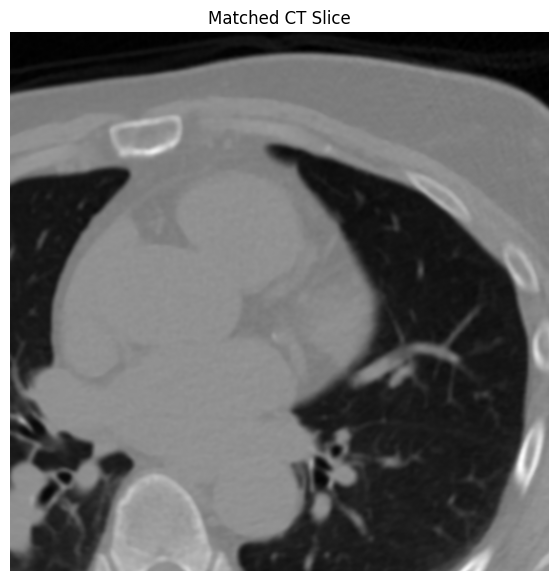

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

plt.imshow(matched_hu, cmap="gray")
plt.title("Matched CT Slice")
plt.axis("off")

plt.show()

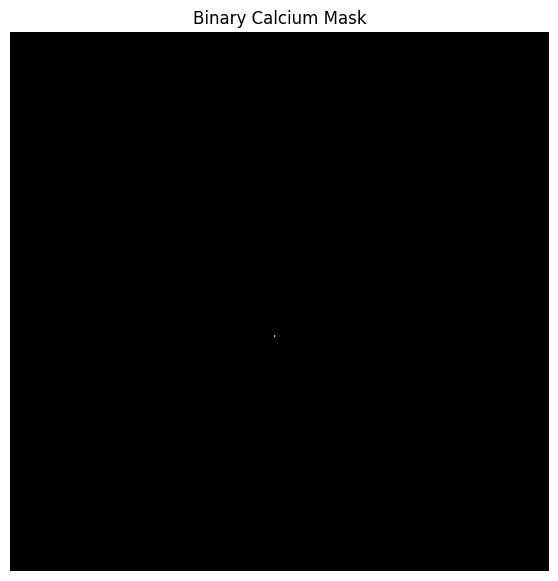

In [65]:
plt.figure(figsize=(7, 7))

plt.imshow(mask, cmap="gray")
plt.title("Binary Calcium Mask")
plt.axis("off")

plt.show()

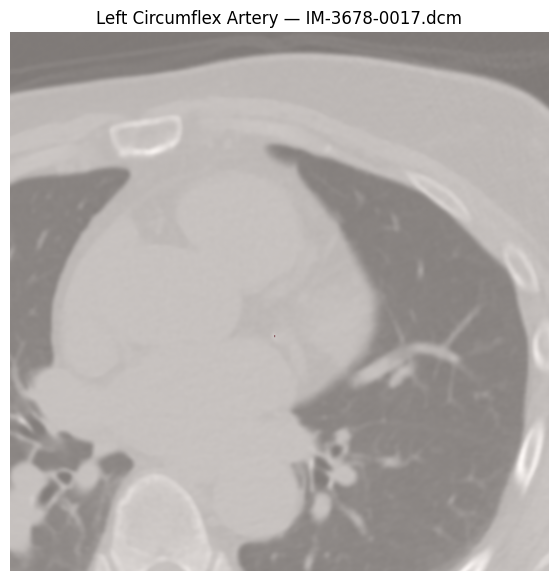

In [66]:
plt.figure(figsize=(7, 7))

plt.imshow(matched_hu, cmap="gray")

plt.imshow(
    mask,
    alpha=0.5,
    cmap="Reds"
)

plt.title(
    f"{sample_roi['Artery']} — "
    f"{best_match['filename']}"
)

plt.axis("off")

plt.show()

In [67]:
patient_135_rois[
    ["ImageIndex", "Artery", "NumberOfPoints"]
]

,ImageIndex,Artery,NumberOfPoints
0,29,Left Circumflex Artery,6
1,30,Left Anterior Descending Artery,16
2,30,Left Circumflex Artery,8


In [68]:
#Merge all ROIs on the same CT slice
slice_groups = patient_135_rois.groupby("ImageIndex")

print("Number of CT slices with calcium:",
      len(slice_groups))

print("ImageIndex values:",
      list(slice_groups.groups.keys()))

Number of CT slices with calcium: 2
ImageIndex values: [29, 30]


In [69]:
#Inspect one group
slice30 = slice_groups.get_group(30)

slice30[
    [
        "Artery",
        "NumberOfPoints"
    ]
]

,Artery,NumberOfPoints
1,Left Anterior Descending Artery,16
2,Left Circumflex Artery,8


In [70]:
# Merged mask for ImageIndex30
import numpy as np
from matplotlib.path import Path

def create_slice_mask(slice_rois, image_shape=(512, 512)):
    """
    Create one binary mask containing all ROIs on one CT slice.
    """

    height, width = image_shape

    # Start with an empty mask
    mask = np.zeros((height, width), dtype=np.uint8)

    # Create the pixel coordinate grid once
    x_grid, y_grid = np.meshgrid(
        np.arange(width),
        np.arange(height)
    )

    pixel_coordinates = np.column_stack(
        (
            x_grid.ravel(),
            y_grid.ravel()
        )
    )

    # Add every ROI on this slice to the same mask
    for _, roi in slice_rois.iterrows():

        points = parse_point_px(roi["Point_px"])

        polygon_path = Path(points)

        roi_mask = polygon_path.contains_points(
            pixel_coordinates,
            radius=0.5
        )

        roi_mask = roi_mask.reshape(height, width)

        # Merge this ROI into the complete slice mask
        mask[roi_mask] = 1

    return mask

In [71]:
slice30_mask = create_slice_mask(
    slice30,
    image_shape=(512, 512)
)

print("Mask shape:", slice30_mask.shape)
print("Pixels inside all ROIs:", slice30_mask.sum())
print("Unique values:", np.unique(slice30_mask))

Mask shape: (512, 512)
Pixels inside all ROIs: 11
Unique values: [0 1]


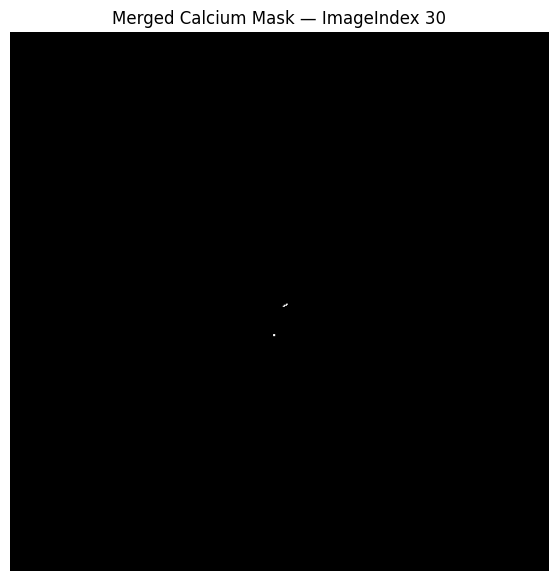

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

plt.imshow(slice30_mask, cmap="gray")
plt.title("Merged Calcium Mask — ImageIndex 30")
plt.axis("off")

plt.show()

In [73]:
for _, roi in slice30.iterrows():
    print(
        roi["Artery"],
        "- polygon points:",
        roi["NumberOfPoints"]
    )

Left Anterior Descending Artery - polygon points: 16
Left Circumflex Artery - polygon points: 8


In [74]:
## Create a mask for one CT slice (multiple ROIs)
slice30_first_roi = slice30.iloc[0]

roi_z_30 = get_roi_z(
    slice30_first_roi["Point_mm"]
)

print("ROI z-position:", roi_z_30)

ROI z-position: -146.5


In [75]:
z_matches_30 = []

for filepath in dicom_paths:

    try:
        temp_ds = pydicom.dcmread(
            filepath,
            stop_before_pixels=True
        )

        if not hasattr(temp_ds, "ImagePositionPatient"):
            continue

        dicom_z = float(
            temp_ds.ImagePositionPatient[2]
        )

        z_matches_30.append({
            "filepath": filepath,
            "filename": os.path.basename(filepath),
            "instance": int(
                getattr(temp_ds, "InstanceNumber", -1)
            ),
            "dicom_z": dicom_z,
            "difference": abs(dicom_z - roi_z_30)
        })

    except Exception:
        continue

best_match_30 = min(
    z_matches_30,
    key=lambda item: item["difference"]
)

best_match_30

{'filepath': '/content/drive/MyDrive/AI_Medical/COCA/raw_data/gated_files/patient/135/Pro_Gated_Calcium_Score_(CS)_3.0_Qr36_2_BestDiast_70_%/IM-3678-0016.dcm',
 'filename': 'IM-3678-0016.dcm',
 'instance': 16,
 'dicom_z': -146.5,
 'difference': 0.0}

In [76]:
matched_ds_30 = pydicom.dcmread(
    best_match_30["filepath"]
)

pixel_array_30 = matched_ds_30.pixel_array.astype(
    np.float32
)

slope_30 = float(
    getattr(matched_ds_30, "RescaleSlope", 1)
)

intercept_30 = float(
    getattr(matched_ds_30, "RescaleIntercept", 0)
)

matched_hu_30 = (
    pixel_array_30 * slope_30
    + intercept_30
)

print("CT shape:", matched_hu_30.shape)
print("Matched file:", best_match_30["filename"])
print("InstanceNumber:", best_match_30["instance"])
print("z difference:", best_match_30["difference"])

CT shape: (512, 512)
Matched file: IM-3678-0016.dcm
InstanceNumber: 16
z difference: 0.0


In [77]:
slice30_mask = create_slice_mask(
    slice30,
    image_shape=matched_hu_30.shape
)

print("Merged mask pixels:", slice30_mask.sum())
print("Unique values:", np.unique(slice30_mask))

Merged mask pixels: 11
Unique values: [0 1]


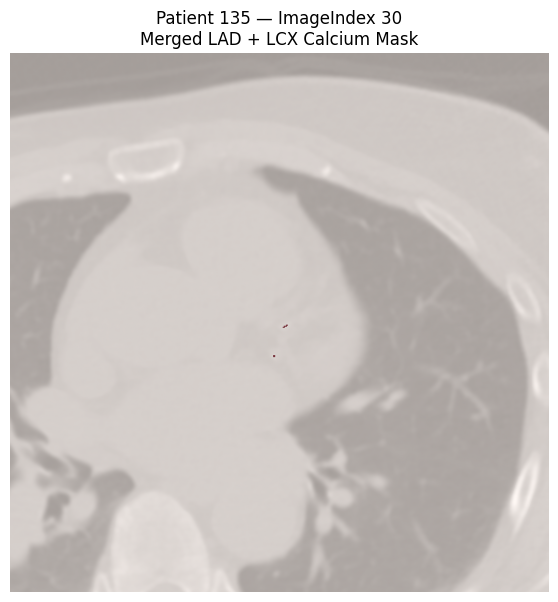

In [78]:
plt.figure(figsize=(7, 7))

plt.imshow(
    matched_hu_30,
    cmap="gray"
)

plt.imshow(
    slice30_mask,
    cmap="Reds",
    alpha=0.65
)

plt.title(
    "Patient 135 — ImageIndex 30\n"
    "Merged LAD + LCX Calcium Mask"
)

plt.axis("off")
plt.show()

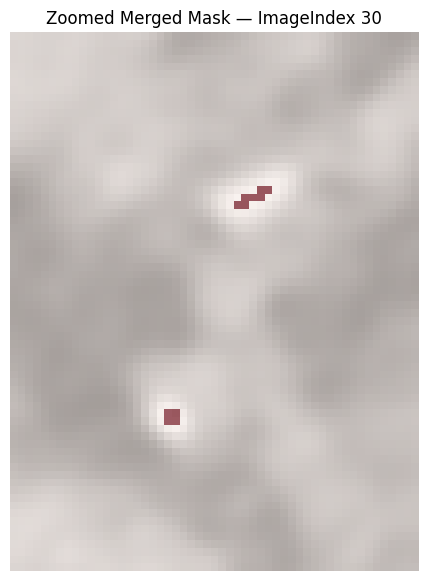

In [79]:
rows, cols = np.where(slice30_mask == 1)

padding = 20

y_min = max(rows.min() - padding, 0)
y_max = min(rows.max() + padding, matched_hu_30.shape[0])

x_min = max(cols.min() - padding, 0)
x_max = min(cols.max() + padding, matched_hu_30.shape[1])

plt.figure(figsize=(7, 7))

plt.imshow(
    matched_hu_30[y_min:y_max, x_min:x_max],
    cmap="gray"
)

plt.imshow(
    slice30_mask[y_min:y_max, x_min:x_max],
    cmap="Reds",
    alpha=0.65
)

plt.title("Zoomed Merged Mask — ImageIndex 30")
plt.axis("off")
plt.show()

In [80]:
#create output folders
import os

output_root = "/content/coca_prepared"

images_dir = os.path.join(output_root, "images")
masks_dir = os.path.join(output_root, "masks")

os.makedirs(images_dir, exist_ok=True)
os.makedirs(masks_dir, exist_ok=True)

print("Images folder:", images_dir)
print("Masks folder:", masks_dir)

Images folder: /content/coca_prepared/images
Masks folder: /content/coca_prepared/masks


In [81]:
print("polygon_df columns:")
print(polygon_df.columns.tolist())

print("\nNumber of polygon ROIs:")
print(len(polygon_df))

print("\nNumber of patients:")
print(polygon_df["Patient"].nunique())

print("\nExample patients:")
print(polygon_df["Patient"].unique()[:10])

polygon_df columns:
['Patient', 'ImageIndex', 'Artery', 'NumberOfPoints', 'Area', 'Point_px', 'Point_mm', 'Min', 'Mean', 'Max']

Number of polygon ROIs:
6232

Number of patients:
449

Example patients:
['0' '1' '10' '100' '101' '102' '103' '104' '105' '106']


In [82]:
# one merged binary mask = 1 CT slice+all ROIs on that slice
import numpy as np
from matplotlib.path import Path

def create_slice_mask(slice_rois, image_shape):
    """
    Merge all polygon ROIs belonging to one CT slice
    into one binary mask.
    """

    height, width = image_shape

    mask = np.zeros((height, width), dtype=np.uint8)

    x_grid, y_grid = np.meshgrid(
        np.arange(width),
        np.arange(height)
    )

    pixel_coordinates = np.column_stack([
        x_grid.ravel(),
        y_grid.ravel()
    ])

    for _, roi in slice_rois.iterrows():

        points = parse_point_px(roi["Point_px"])

        if points is None or len(points) < 3:
            continue

        polygon = Path(points)

        roi_mask = polygon.contains_points(
            pixel_coordinates,
            radius=0.5
        )

        roi_mask = roi_mask.reshape(height, width)

        # Merge the current ROI into the full slice mask
        mask[roi_mask] = 1

    return mask

In [83]:
# Create a function for HU conversion
def dicom_to_hu(ds):
    """
    Convert a DICOM pixel array into Hounsfield Units.
    """

    image = ds.pixel_array.astype(np.float32)

    slope = float(getattr(ds, "RescaleSlope", 1))
    intercept = float(getattr(ds, "RescaleIntercept", 0))

    hu_image = image * slope + intercept

    return hu_image

In [84]:
# Get the ROI z-position
import ast

def get_roi_z(point_mm):
    """
    Extract the z-coordinate from an ROI's Point_mm values.
    """

    if isinstance(point_mm, str):
        point_mm = ast.literal_eval(point_mm)

    point_mm = np.asarray(point_mm, dtype=float)

    if point_mm.ndim != 2 or point_mm.shape[1] < 3:
        raise ValueError("Point_mm must contain x, y, and z coordinates.")

    return float(np.mean(point_mm[:, 2]))

In [85]:
#Build a DICOM index for one patient
import glob
import pydicom

def build_patient_dicom_index(patient_folder):
    """
    Read DICOM metadata for one patient and store each slice's
    file path and z-position.
    """

    dicom_index = []

    all_files = glob.glob(
        os.path.join(patient_folder, "**", "*"),
        recursive=True
    )

    for filepath in all_files:

        if not os.path.isfile(filepath):
            continue

        try:
            ds = pydicom.dcmread(
                filepath,
                stop_before_pixels=True,
                force=True
            )

            if not hasattr(ds, "ImagePositionPatient"):
                continue

            z_position = float(ds.ImagePositionPatient[2])

            dicom_index.append({
                "filepath": filepath,
                "z": z_position,
                "instance": int(
                    getattr(ds, "InstanceNumber", -1)
                )
            })

        except Exception:
            continue

    return dicom_index

In [86]:
# Find the DICOM slice matching one ROIs
def find_matching_dicom(roi_z, dicom_index):
    """
    Find the DICOM slice with the closest z-coordinate
    to the XML ROI.
    """

    if len(dicom_index) == 0:
        return None

    best_match = min(
        dicom_index,
        key=lambda item: abs(item["z"] - roi_z)
    )

    best_match = best_match.copy()
    best_match["z_difference"] = abs(
        best_match["z"] - roi_z
    )

    return best_match

In [87]:
dicom_root = "/content/drive/MyDrive/AI_Medical/COCA/raw_data/gated_files/patient"

In [88]:
print(os.listdir(dicom_root)[:20])

['.DS_Store', '135', '307', '763', '551', '61', '95', '338', '556', '764', '300', '132', '59', '569', '92', '66', '336', '104', '560', '752']


In [89]:
# To find one patient folder
def find_patient_folder(patient_id, dicom_root):
    """
    Find the DICOM folder belonging to one patient.
    """

    patient_id = str(patient_id)

    possible_names = [
        patient_id,
        f"patient_{patient_id}",
        f"Patient_{patient_id}",
        f"patient{patient_id}",
        f"Patient{patient_id}"
    ]

    for folder_name in possible_names:

        folder_path = os.path.join(
            dicom_root,
            folder_name
        )

        if os.path.isdir(folder_path):
            return folder_path

    # Search nested folders if the direct names do not work
    matches = glob.glob(
        os.path.join(
            dicom_root,
            "**",
            f"*{patient_id}*"
        ),
        recursive=True
    )

    matches = [
        path for path in matches
        if os.path.isdir(path)
    ]

    if len(matches) > 0:
        return matches[0]

    return None

In [90]:
# test tp find 135
test_folder = find_patient_folder(
    135,
    dicom_root
)

print(test_folder)

/content/drive/MyDrive/AI_Medical/COCA/raw_data/gated_files/patient/135


Load patient ROIs

↓

Group them by ImageIndex

↓

Find the correct DICOM slice

↓

Merge all ROIs

↓

Save the image and mask

In [91]:
import re
import numpy as np

def get_roi_z(point_mm):
    """
    Extract the average z-coordinate from Point_mm.

    Works when Point_mm contains coordinate tuples stored as text.
    """

    # Convert everything into text
    text = str(point_mm)

    # Extract all numbers, including negative and decimal values
    numbers = re.findall(
        r"[-+]?(?:\d*\.\d+|\d+)(?:[eE][-+]?\d+)?",
        text
    )

    numbers = np.array(
        [float(number) for number in numbers],
        dtype=float
    )

    # Each point should contain x, y, z
    if len(numbers) < 3:
        raise ValueError(
            f"Could not find x, y, z coordinates in Point_mm: {point_mm}"
        )

    if len(numbers) % 3 != 0:
        raise ValueError(
            f"Number of coordinate values is not divisible by 3: "
            f"{len(numbers)}"
        )

    points = numbers.reshape(-1, 3)

    # Column 0 = x, column 1 = y, column 2 = z
    return float(points[:, 2].mean())

In [92]:
example_point_mm = patient_135_data.iloc[0]["Point_mm"]

print("Original value:")
print(example_point_mm)

print("\nExtracted z-position:")
print(get_roi_z(example_point_mm))

Original value:
['(48.950558, -165.062500, -149.500000)', '(48.950558, -164.720703, -149.500000)', '(49.291016, -164.380249, -149.500000)', '(49.631474, -164.720703, -149.500000)', '(49.631474, -165.062500, -149.500000)', '(49.291016, -165.402954, -149.500000)']

Extracted z-position:
-149.5


In [93]:
saved_135, errors_135 = process_patient(
    patient_id=135,
    patient_rois=patient_135_data,
    dicom_root=dicom_root,
    images_dir=images_dir,
    masks_dir=masks_dir
)

print("Saved slices:", len(saved_135))
print("Errors:", len(errors_135))

Saved slices: 2
Errors: 0


In [94]:
#Process all patients
from tqdm.auto import tqdm
import pandas as pd

all_saved_records = []
all_error_records = []

patient_groups = polygon_df.groupby("Patient")

for patient_id, patient_rois in tqdm(
    patient_groups,
    total=polygon_df["Patient"].nunique(),
    desc="Processing patients"
):

    saved_records, error_records = process_patient(
        patient_id=patient_id,
        patient_rois=patient_rois,
        dicom_root=dicom_root,
        images_dir=images_dir,
        masks_dir=masks_dir
    )

    all_saved_records.extend(saved_records)
    all_error_records.extend(error_records)

Processing patients:   0%|          | 0/449 [00:00<?, ?it/s]

In [95]:
#Create the dataset summmary
dataset_index = pd.DataFrame(all_saved_records)
error_log = pd.DataFrame(all_error_records)

print("Successfully saved image-mask pairs:", len(dataset_index))
print("Number of errors:", len(error_log))
print("Patients successfully processed:", dataset_index["Patient"].nunique())

Successfully saved image-mask pairs: 3671
Number of errors: 0
Patients successfully processed: 449


In [96]:
dataset_index.head()

,Patient,ImageIndex,Filename,DICOMFile,InstanceNumber,ROI_z,DICOM_z,ZDifference,NumberOfROIs,MaskPixels,Height,Width
0,0,34,patient_0_slice_34.npy,/content/drive/MyDrive/AI_Medical/COCA/raw_dat...,23,-183.25,-183.25,0.0,1,13,512,512
1,1,12,patient_1_slice_12.npy,/content/drive/MyDrive/AI_Medical/COCA/raw_dat...,45,-214.75,-214.75,0.0,1,18,512,512
2,1,19,patient_1_slice_19.npy,/content/drive/MyDrive/AI_Medical/COCA/raw_dat...,38,-193.75,-193.75,0.0,1,10,512,512
3,1,26,patient_1_slice_26.npy,/content/drive/MyDrive/AI_Medical/COCA/raw_dat...,31,-172.75,-172.75,0.0,1,4,512,512
4,1,27,patient_1_slice_27.npy,/content/drive/MyDrive/AI_Medical/COCA/raw_dat...,30,-169.75,-169.75,0.0,2,71,512,512


In [98]:
#Save the index files
dataset_index.to_csv(
    os.path.join(output_root, "dataset_index.csv"),
    index=False
)

error_log.to_csv(
    os.path.join(output_root, "error_log.csv"),
    index=False
)

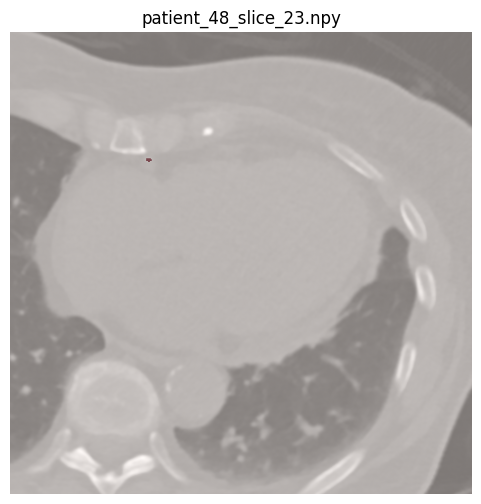

Image shape: (512, 512)
Mask shape: (512, 512)
Positive pixels: 19


In [99]:
import random
import numpy as np
import matplotlib.pyplot as plt

sample = dataset_index.sample(1).iloc[0]

image = np.load(
    os.path.join(images_dir, sample["Filename"])
)

mask = np.load(
    os.path.join(masks_dir, sample["Filename"])
)

plt.figure(figsize=(6,6))
plt.imshow(image, cmap="gray")
plt.imshow(mask, cmap="Reds", alpha=0.5)
plt.title(sample["Filename"])
plt.axis("off")
plt.show()

print("Image shape:", image.shape)
print("Mask shape:", mask.shape)
print("Positive pixels:", mask.sum())

In [100]:
print("Successfully saved image-mask pairs:", len(dataset_index))
print("Number of errors:", len(error_log))

Successfully saved image-mask pairs: 3671
Number of errors: 0


In [101]:
dataset_index = pd.DataFrame(all_saved_records)
error_log = pd.DataFrame(all_error_records)

print("Total image-mask pairs:", len(dataset_index))
print("Errors:", len(error_log))
print("Patients:", dataset_index["Patient"].nunique())

Total image-mask pairs: 3671
Errors: 0
Patients: 449


In [103]:
dataset_index.to_csv(
    os.path.join(output_root, "dataset_index.csv"),
    index=False
)

error_log.to_csv(
    os.path.join(output_root, "error_log.csv"),
    index=False
)

In [104]:
# Create a small dataset summary and save it into csv
dataset_summary = pd.DataFrame({
    "Metric": [
        "Annotated patients processed",
        "Image-mask pairs generated",
        "Preprocessing errors",
        "Image height",
        "Image width",
        "Mask format"
    ],
    "Value": [
        dataset_index["Patient"].nunique(),
        len(dataset_index),
        len(error_log),
        dataset_index["Height"].mode()[0],
        dataset_index["Width"].mode()[0],
        "Binary: 0 = background, 1 = calcium"
    ]
})

dataset_summary

,Metric,Value
0,Annotated patients processed,449
1,Image-mask pairs generated,3671
2,Preprocessing errors,0
3,Image height,512
4,Image width,512
5,Mask format,"Binary: 0 = background, 1 = calcium"


In [105]:
dataset_summary.to_csv(
    "/content/dataset_summary.csv",
    index=False
)

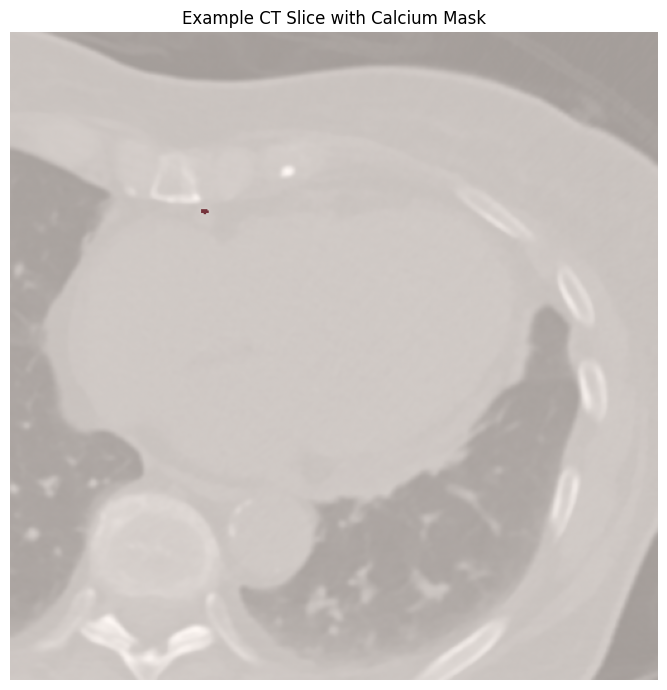

In [106]:
# Save the example figure
sample = dataset_index[
    dataset_index["Filename"] == "patient_48_slice_23.npy"
].iloc[0]

image = np.load(
    os.path.join(images_dir, sample["Filename"])
)

mask = np.load(
    os.path.join(masks_dir, sample["Filename"])
)

plt.figure(figsize=(7, 7))
plt.imshow(image, cmap="gray")
plt.imshow(mask, cmap="Reds", alpha=0.65)
plt.title("Example CT Slice with Calcium Mask")
plt.axis("off")
plt.tight_layout()

plt.savefig(
    "/content/example_image_mask_pair.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()